### Business Question 2 — Menu Engineering: Which Products Win Where, and Does It Vary by Branch?

#### Methodology (Revenue/Volume Proxy — Not Margin-Based)

> **Important caveat:** No cost or margin data exists in this dataset. All analysis below is a revenue-and-volume proxy for menu engineering, not a true margin-based analysis. Quadrant labels (e.g. "Core", "Premium/Niche") describe revenue and volume performance only.

---

**Data source:** `qbs_bronze.sales_raw` — re-read fresh from source.
**Branch proxy:** `city` column (one city = one branch).
**Revenue field derived as:** `price × quantity` per transaction row.

---

#### Definitions

| Metric | Definition |
|---|---|
| `total_revenue` | SUM(price × quantity) per (city, product) |
| `total_quantity` | SUM(quantity) per (city, product) |
| `revenue_tier` | NTILE(2) of `total_revenue` PARTITION BY city — tile 2 = high, tile 1 = low |
| `volume_tier` | NTILE(2) of `total_quantity` PARTITION BY city — tile 2 = high, tile 1 = low |
| `quadrant` | Core (rev 2 + vol 2) \| Premium/Niche (rev 2 + vol 1) \| Value Driver (rev 1 + vol 2) \| Underperformer (rev 1 + vol 1) |
| `revenue_rank_per_branch` | RANK of product by `total_revenue` DESC within each city (1 = highest) |
| `rank_volatility` | STDDEV of `revenue_rank_per_branch` across cities, grouped by product |

**Interpretation of rank_volatility:**
- **High volatility** → a product ranks #1 in one city but last in another — "star in one city, underperformer in another"
- **Low volatility** → consistent rank across all branches — globally dominant or globally weak

---

#### Amazon Q / Window-Function Logic (as it would be expressed in SQL)

```sql
-- Step 1: Aggregate per (city, product)
WITH branch_product AS (
    SELECT
        city                            AS branch_id,
        product                         AS product_id,
        SUM(price * quantity)           AS total_revenue,
        SUM(quantity)                   AS total_quantity
    FROM sales_raw
    WHERE price >= 0 AND quantity >= 0
    GROUP BY city, product
),
-- Step 2: Assign NTILE tiers and RANK within each branch
tiered AS (
    SELECT *,
        NTILE(2) OVER (PARTITION BY branch_id ORDER BY total_revenue) AS revenue_tier,
        NTILE(2) OVER (PARTITION BY branch_id ORDER BY total_quantity) AS volume_tier,
        RANK()   OVER (PARTITION BY branch_id ORDER BY total_revenue DESC) AS revenue_rank
    FROM branch_product
),
-- Step 3: Classify quadrant
classified AS (
    SELECT *,
        CASE
            WHEN revenue_tier = 2 AND volume_tier = 2 THEN 'Core'
            WHEN revenue_tier = 2 AND volume_tier = 1 THEN 'Premium/Niche'
            WHEN revenue_tier = 1 AND volume_tier = 2 THEN 'Value Driver'
            ELSE 'Underperformer'
        END AS quadrant
    FROM tiered
)
-- Step 4: Rank volatility — STDDEV of rank across branches
SELECT
    product_id,
    STDDEV(revenue_rank) AS rank_volatility
FROM classified
GROUP BY product_id
ORDER BY rank_volatility DESC;
```

This SQL mirrors exactly what the Python cells below compute using pandas window-function equivalents (`groupby`, `rank`, `std`).


In [0]:
import pandas as pd
import numpy as np

# ── 1. Re-read fresh from source ─────────────────────────────────────────────
raw = pd.read_catalog_table(database="qbs_smus_bronze", table="sales_raw")
raw.columns = [c.strip().lower().replace(" ", "_") for c in raw.columns]
raw["price"]    = pd.to_numeric(raw["price"],    errors="coerce")
raw["quantity"] = pd.to_numeric(raw["quantity"], errors="coerce")
raw["product"]  = raw["product"].str.strip()
raw["city"]     = raw["city"].str.strip()
raw = raw.drop_duplicates()
raw = raw[(raw["price"] >= 0) & (raw["quantity"] >= 0)].dropna(subset=["price", "quantity"])
raw["revenue"]  = raw["price"] * raw["quantity"]
print(f"Fresh load: {raw.shape[0]:,} clean rows | {raw['city'].nunique()} branches | {raw['product'].nunique()} products")

# ── 2. Aggregate per (city, product) ─────────────────────────────────────────
bp = (
    raw.groupby(["city", "product"], as_index=False)
    .agg(total_revenue=("revenue", "sum"), total_quantity=("quantity", "sum"))
)

# ── 3. NTILE(2) revenue & volume tiers — partitioned by city ─────────────────
def ntile2(series):
    """Rank values into 2 equal tiles; ties go to lower tile."""
    ranked = series.rank(method="first")
    cutoff = len(series) / 2
    return ranked.apply(lambda r: 2 if r > cutoff else 1)

bp["revenue_tier"] = bp.groupby("city")["total_revenue"].transform(ntile2)
bp["volume_tier"]  = bp.groupby("city")["total_quantity"].transform(ntile2)

# ── 4. Quadrant classification ────────────────────────────────────────────────
def classify(row):
    if   row.revenue_tier == 2 and row.volume_tier == 2: return "Core"
    elif row.revenue_tier == 2 and row.volume_tier == 1: return "Premium/Niche"
    elif row.revenue_tier == 1 and row.volume_tier == 2: return "Value Driver"
    else:                                                return "Underperformer"

bp["quadrant"] = bp.apply(classify, axis=1)

# ── 5. Revenue rank per branch (1 = highest revenue in that city) ─────────────
bp["revenue_rank"] = (
    bp.groupby("city")["total_revenue"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# ── 6. Rank volatility = STDDEV of revenue_rank across cities, per product ────
volatility = (
    bp.groupby("product")["revenue_rank"]
    .std(ddof=1)
    .reset_index()
    .rename(columns={"revenue_rank": "rank_volatility"})
    .sort_values("rank_volatility", ascending=False)
)
volatility["rank_volatility"] = volatility["rank_volatility"].round(3)

print("\n--- Rank Volatility by Product (high = 'star in one city, underperformer in another') ---")
print(volatility.to_string(index=False))

# ── 7. Full matrix: quadrant per (product x branch) ──────────────────────────
menu_matrix = bp[["city", "product", "total_revenue", "total_quantity",
                   "revenue_tier", "volume_tier", "quadrant", "revenue_rank"]].sort_values(
    ["product", "city"]
)

# ── 8. Expose for downstream use ──────────────────────────────────────────────
menu_engineering_df = menu_matrix.merge(volatility, on="product", how="left")
menu_engineering_df["total_revenue"] = menu_engineering_df["total_revenue"].round(2)
menu_engineering_df["total_quantity"] = menu_engineering_df["total_quantity"].round(2)


Fresh load: 259 clean rows | 6 branches | 5 products

--- Rank Volatility by Product (high = 'star in one city, underperformer in another') ---
           product  rank_volatility
         Beverages            0.894
             Fries            0.894
Chicken Sandwiches            0.837
           Burgers            0.000
     Sides & Other            0.000


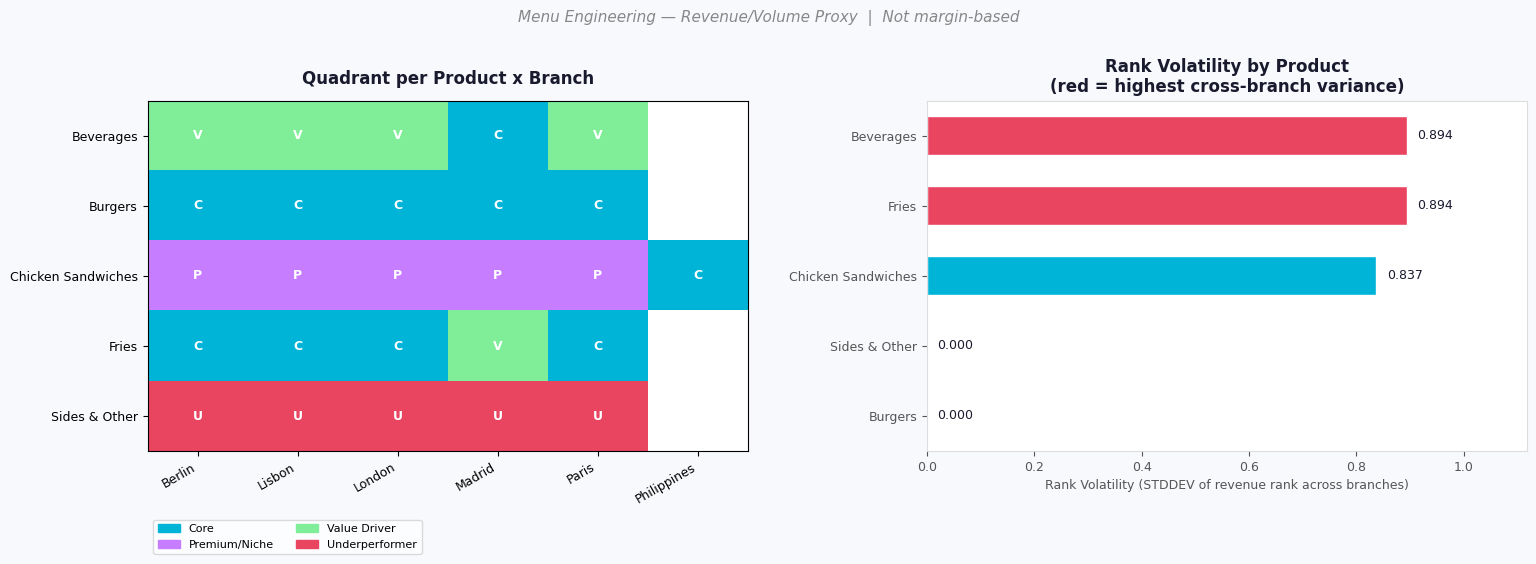


Highest rank volatility: 'Beverages' (stddev = 0.894)
  -> This product's revenue rank swings most across branches.
     It is a 'star in one city, underperformer in another'.

Quadrant summary across all branches:
quadrant
Core              [Beverages, Burgers, Chicken Sandwiches, Fries]
Premium/Niche                                [Chicken Sandwiches]
Underperformer                                    [Sides & Other]
Value Driver                                   [Beverages, Fries]


In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BRAND  = "#1a1a2e"
BG     = "#f7f9fc"
Q_COLORS = {
    "Core":           "#00b4d8",
    "Premium/Niche":  "#c77dff",
    "Value Driver":   "#80ed99",
    "Underperformer": "#e94560",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

# ── Left: Quadrant heatmap — product x city ────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("white")

cities   = sorted(menu_engineering_df["city"].unique())
products = sorted(menu_engineering_df["product"].unique())
quadrant_order = ["Core", "Premium/Niche", "Value Driver", "Underperformer"]
q_num = {q: i for i, q in enumerate(quadrant_order)}

matrix = pd.DataFrame(index=products, columns=cities, dtype=float)
qlabel = pd.DataFrame(index=products, columns=cities, dtype=str)
for _, row in menu_engineering_df.drop_duplicates(["city", "product"]).iterrows():
    matrix.loc[row["product"], row["city"]] = q_num.get(row["quadrant"], np.nan)
    qlabel.loc[row["product"], row["city"]] = row["quadrant"]

cmap = plt.cm.colors.ListedColormap(
    [Q_COLORS[q] for q in quadrant_order]
) if False else None

from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap([Q_COLORS[q] for q in quadrant_order])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

data = matrix.values.astype(float)
im = ax1.imshow(data, cmap=cmap, norm=norm, aspect="auto")

ax1.set_xticks(range(len(cities)))
ax1.set_xticklabels(cities, rotation=30, ha="right", fontsize=9)
ax1.set_yticks(range(len(products)))
ax1.set_yticklabels(products, fontsize=9)
ax1.set_title("Quadrant per Product x Branch", fontsize=12, fontweight="bold", color=BRAND, pad=12)

for r, prod in enumerate(products):
    for c, city in enumerate(cities):
        lbl = qlabel.loc[prod, city]
        abbrev = {"Core": "C", "Premium/Niche": "P", "Value Driver": "V", "Underperformer": "U"}.get(lbl, "")
        ax1.text(c, r, abbrev, ha="center", va="center", fontsize=9, fontweight="bold", color="white")

legend_patches = [mpatches.Patch(color=Q_COLORS[q], label=q) for q in quadrant_order]
ax1.legend(handles=legend_patches, loc="upper left", bbox_to_anchor=(0, -0.18),
           ncol=2, fontsize=8, framealpha=0.7)

# ── Right: Rank volatility bar chart ──────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("white")
vol = volatility.sort_values("rank_volatility", ascending=True)
bar_colors = ["#e94560" if v == vol["rank_volatility"].max() else "#00b4d8"
              for v in vol["rank_volatility"]]
bars = ax2.barh(vol["product"], vol["rank_volatility"], color=bar_colors, edgecolor="white", height=0.55)
for bar, v in zip(bars, vol["rank_volatility"]):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f"{v:.3f}", va="center", fontsize=9, color=BRAND)
ax2.set_xlabel("Rank Volatility (STDDEV of revenue rank across branches)", fontsize=9, color="#555")
ax2.set_title("Rank Volatility by Product\n(red = highest cross-branch variance)", fontsize=12,
              fontweight="bold", color=BRAND)
ax2.set_xlim(0, vol["rank_volatility"].max() * 1.25)
for sp in ax2.spines.values():
    sp.set_edgecolor("#ddd")
ax2.tick_params(colors="#555", labelsize=9)

plt.tight_layout(pad=3)
plt.suptitle("Menu Engineering — Revenue/Volume Proxy  |  Not margin-based",
             y=1.01, fontsize=11, color="#888", style="italic")
plt.show()

# ── Summary call-out ──────────────────────────────────────────────────────────
top_volatile = volatility.iloc[0]
print(f"\nHighest rank volatility: '{top_volatile['product']}' (stddev = {top_volatile['rank_volatility']})")
print("  -> This product's revenue rank swings most across branches.")
print("     It is a 'star in one city, underperformer in another'.\n")
print("Quadrant summary across all branches:")
print(menu_engineering_df.groupby("quadrant")["product"].apply(lambda x: sorted(x.unique())).to_string())
